# SeqOptPlot.hypervolume — convergence trace\n\nThe per-generation hypervolume of the front (`SeqOpt.trajectory_`) is non-decreasing under `(mu+lambda)` elitism on a fixed seed.

In [1]:
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
import aaanalysis.utils as ut
aa.options["verbose"] = False

# A single wild-type (position-based: sequence + TMD coordinates) ...
df_seq = pd.DataFrame({"entry": ["P1"],
    "sequence": ["MKLAGTWYVFAILMVFWCGSTNQDEHKRPYLAGTWYVFAI"],
    "tmd_start": [11], "tmd_stop": [20]})
# ... a small CPP-style df_feat over the TMD (real scales, mean_dif + feat_importance + positions),
scales = list(aa.load_scales().columns[:4])
df_feat = pd.DataFrame({
    "feature": [f"TMD-Segment(1,1)-{s}" for s in scales],
    "category": ["Polarity","ASA/Volume","Polarity","Energy"],
    "subcategory": ["Hydrophobicity","Volume","Charge","Free energy"],
    "scale_name": scales, "abs_auc": [.30,.25,.20,.10], "abs_mean_dif": [.40,.30,.20,.10],
    "mean_dif": [.40,-.30,.20,-.10], "std_test": [.1]*4, "std_ref": [.1]*4,
    "feat_importance": [40.,30.,20.,10.]})
# ... and a fitted classifier (exposes predict_proba) used as the fitness engine.
ref = pd.DataFrame({"entry": [f"R{i}" for i in range(8)],
    "sequence": list(df_seq["sequence"]) * 4 if False else
        ["MKLAGTWYVFAILMVFWCGSTNQDEHKRPYLAGTWYVFAI",
         "ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMNPQRSTVWY"] * 4,
    "tmd_start": [11]*8, "tmd_stop": [20]*8})
labels = [1,0]*4
sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=list(df_feat["feature"]),
                                 df_parts=sf.get_df_parts(df_seq=ref),
                                 df_scales=aa.load_scales()), float)
model = RandomForestClassifier(n_estimators=20, random_state=0).fit(X, labels)


/Users/stephanbreimann/Programming/1Packages/wt-seqopt/aaanalysis/feature_engineering/_backend/cpp_run.py:163: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


In [2]:
# Two objectives: maximize the model prediction shift, minimize the number of mutations.
objectives = [("activity", "max", "delta_pred"), ("parsimony", "min", "n_mut")]
seqopt = aa.SeqOpt(mode="importance", model=model, random_state=42)
df_pareto = seqopt.run(df_seq=df_seq, df_feat=df_feat, objectives=objectives,
                       algorithm="nsga2", pop_size=20, n_gen=10, n_mut_max=4,
                       crossover="uniform", mutation="substitution", cx_prob=0.5,
                       mut_prob=0.2, survival="mu_plus_lambda", region="tmd", init="random")
aa.display_df(df_pareto, n_rows=10, show_shape=True)


DataFrame shape: (1, 8)


,entry,variant,n_mut,sequence_mut,activity,parsimony,rank,crowding
1,P1,,0,MKLAGTWYVFAILMV...HKRPYLAGTWYVFAI,0.000000,0.000000,0,inf


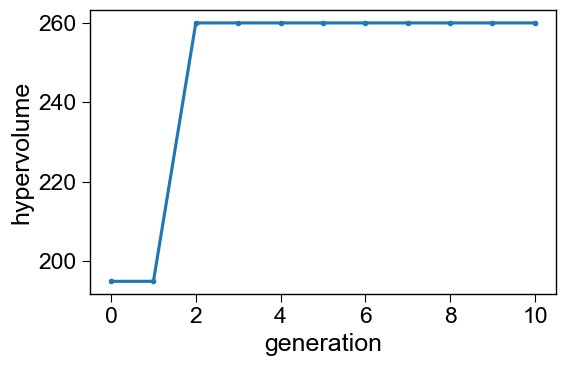

In [3]:
import matplotlib.pyplot as plt
aa.plot_settings()
aa.SeqOptPlot().hypervolume(trajectory=seqopt.trajectory_)
plt.tight_layout()
plt.show()